:::writing “”" GLOBAL PROTEST ANALYSIS – RISK & ESCALATION MODULE
Project: Global Protest Risk & Escalation Analysis

This module performs advanced analytical modeling on the global protest dataset.

The goal is to quantify protest instability, violence risk, and escalation dynamics

across countries and cities.

Unlike the overview module which focuses on descriptive exploration, this script

builds analytical indicators that can be used for risk monitoring and geopolitical

analysis.

Core Concepts:

Protest Violence Risk
Government Repression Rate
Protest Escalation Index
City-Level Instability
Country Risk Scoring
Key Analytical Goals:

Identify countries with the highest protest violence rates
Measure government repression against protests
Detect escalation patterns in protest activity
Rank cities and countries by protest risk
Generate analytical datasets for Power BI dashboards
Main Indicators Built:

Violence Rate
Repression Rate
Protest Frequency
Escalation Index
Composite Protest Risk Score
Output Files:

country_risk_scores.csv

city_risk_scores.csv

escalation_index.csv

Dataset Used:

Protest_pg_ready.csv

Author: Data Analysis Project

Module: Risk & Escalation Analysis

“”"

:::

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20404\10870736.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


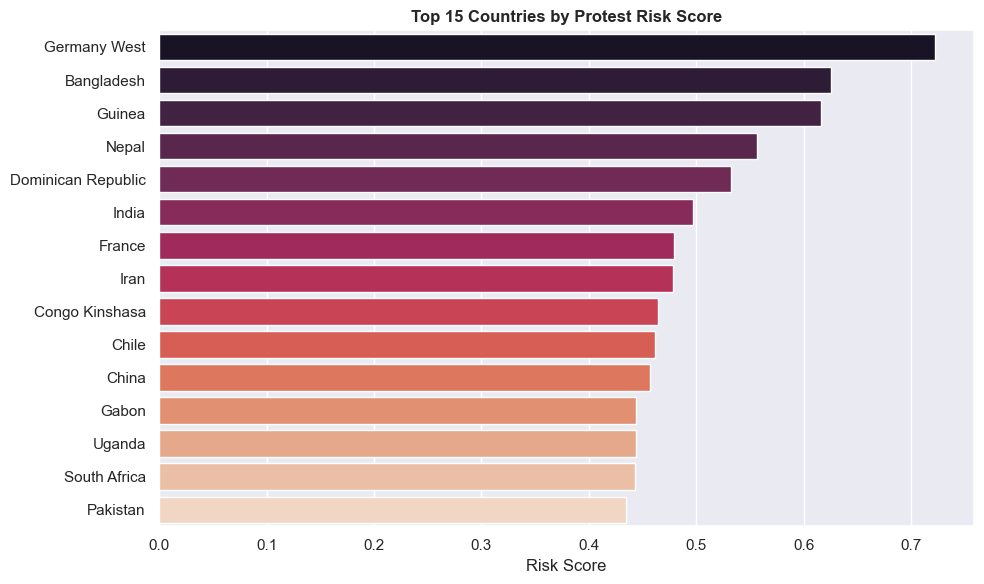

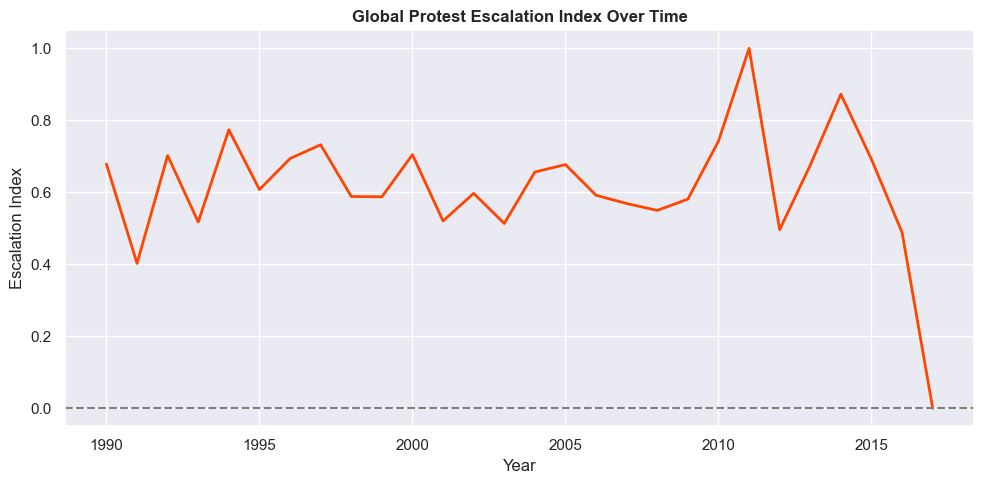

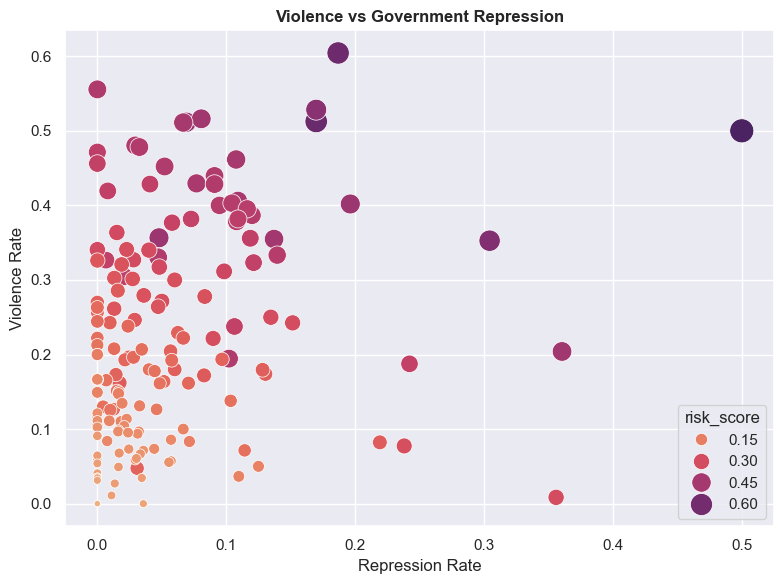

In [1]:
"""
GLOBAL PROTEST ANALYSIS – RISK & ESCALATION (PYTHON CORE)
-------------------------------------------------------

Purpose:
Deep analytical modeling of protest violence, repression,
and escalation dynamics using Python only.

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid", palette="flare")

# ============================
# Load Data
# ============================

df = pd.read_csv("Protest_pg_ready.csv", sep=";", low_memory=False)

# ============================
# Basic Cleaning
# ============================

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Protester Violence"] = pd.to_numeric(df["Protester Violence"], errors="coerce").fillna(0)

df = df.dropna(subset=["Country name"])

# ============================
# Government Repression Proxy
# ============================

response_col = "Primary State Response to protests [Response 1]"

df[response_col] = df[response_col].fillna("").astype(str)

repression_keywords = [
    "Repression",
    "Arrest",
    "Police",
    "Force",
    "Violence",
    "Crackdown"
]

df["is_repression"] = df[response_col].str.contains(
    "|".join(repression_keywords),
    case=False,
    regex=True
).astype(int)

# ============================
# Protest Duration (Days)
# ============================

df["start_date"] = pd.to_datetime(
    dict(
        year=df["Start Year"],
        month=df["Start Month"],
        day=df["Start Day"]
    ),
    errors="coerce"
)

df["end_date"] = pd.to_datetime(
    dict(
        year=df["End Year"],
        month=df["End Month"],
        day=df["End Day"]
    ),
    errors="coerce"
)

df["duration_days"] = (df["end_date"] - df["start_date"]).dt.days
df["duration_days"] = df["duration_days"].clip(lower=0)

# ============================
# Country-Level Indicators
# ============================

country_stats = df.groupby("Country name").agg(
    protest_count=("Protest ID #", "count"),
    violence_rate=("Protester Violence", "mean"),
    repression_rate=("is_repression", "mean"),
    avg_duration=("duration_days", "mean")
)

# ============================
# Normalize Indicators
# ============================

def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

country_stats["violence_norm"] = normalize(country_stats["violence_rate"])
country_stats["repression_norm"] = normalize(country_stats["repression_rate"])
country_stats["frequency_norm"] = normalize(country_stats["protest_count"])

# ============================
# Protest Risk Score
# ============================

country_stats["risk_score"] = (
    0.45 * country_stats["violence_norm"] +
    0.35 * country_stats["repression_norm"] +
    0.20 * country_stats["frequency_norm"]
)

country_stats = country_stats.sort_values("risk_score", ascending=False)

# ============================
# Escalation Index (Global)
# ============================

yearly = df.groupby("Year").agg(
    protests=("Protest ID #", "count"),
    violence_rate=("Protester Violence", "mean")
)

yearly["growth_rate"] = yearly["protests"].pct_change()
yearly["escalation_index"] = normalize(
    yearly["growth_rate"].fillna(0) + yearly["violence_rate"]
)

# ============================
# 📊 VISUALIZATIONS
# ============================

# 1 Top High-Risk Countries
plt.figure(figsize=(10,6))
top = country_stats.head(15)
sns.barplot(
    y=top.index,
    x=top["risk_score"],
    palette="rocket"
)
plt.title("Top 15 Countries by Protest Risk Score", weight="bold")
plt.xlabel("Risk Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 2 Escalation Trend
plt.figure(figsize=(10,5))
sns.lineplot(
    data=yearly,
    x=yearly.index,
    y="escalation_index",
    color="#FF4500",
    linewidth=2
)
plt.axhline(0, linestyle="--", color="gray")
plt.title("Global Protest Escalation Index Over Time", weight="bold")
plt.xlabel("Year")
plt.ylabel("Escalation Index")
plt.tight_layout()
plt.show()

# 3 Violence vs Repression
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=country_stats,
    x="repression_rate",
    y="violence_rate",
    size="risk_score",
    sizes=(20,300),
    hue="risk_score",
    palette="flare"
)
plt.title("Violence vs Government Repression", weight="bold")
plt.xlabel("Repression Rate")
plt.ylabel("Violence Rate")
plt.tight_layout()
plt.show()





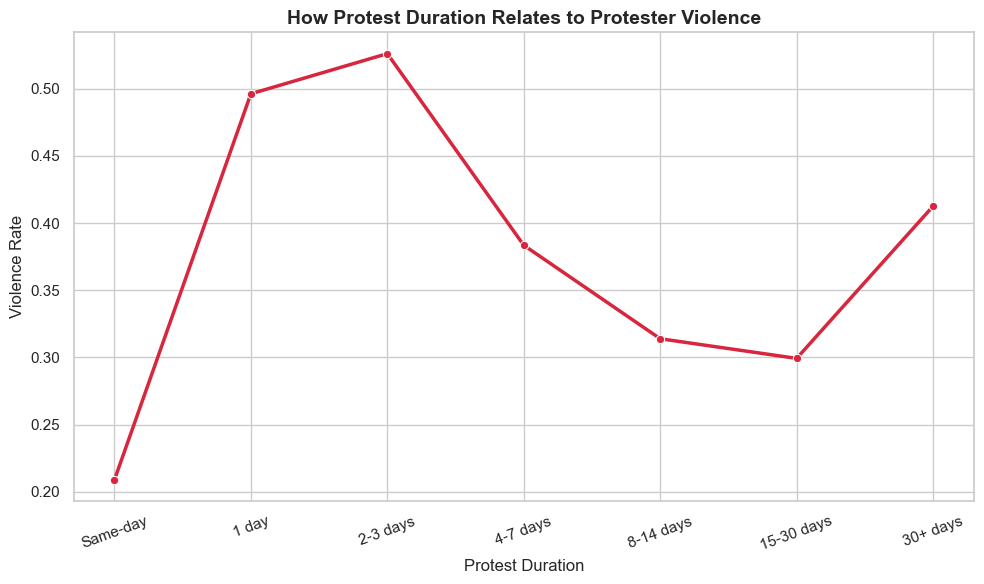

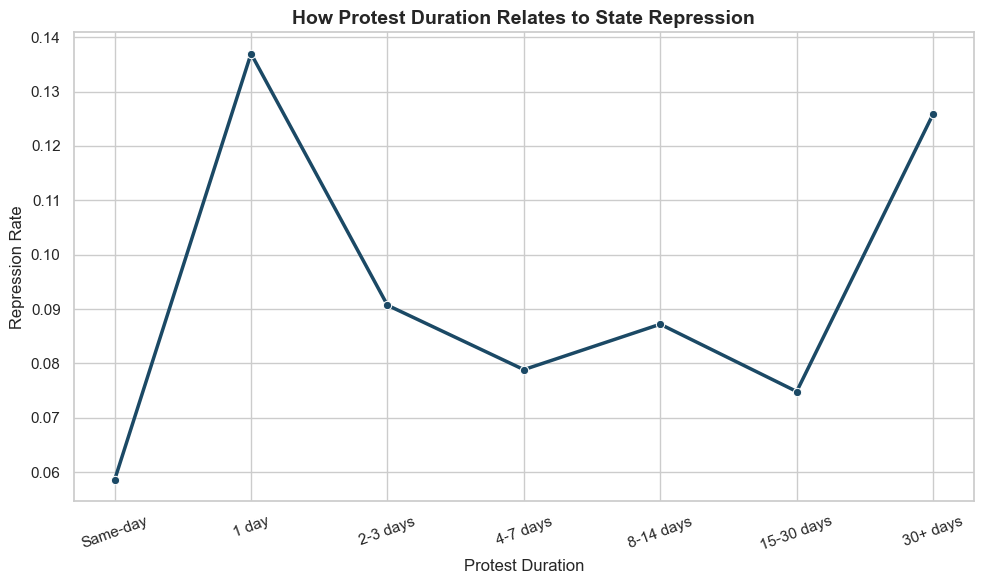

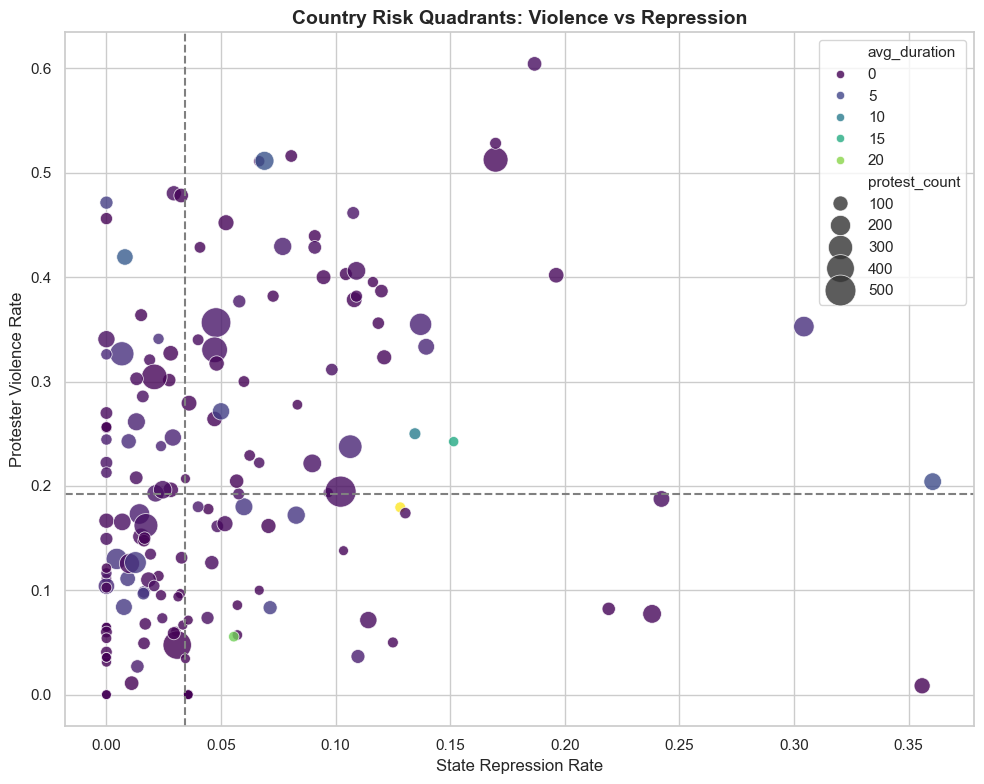

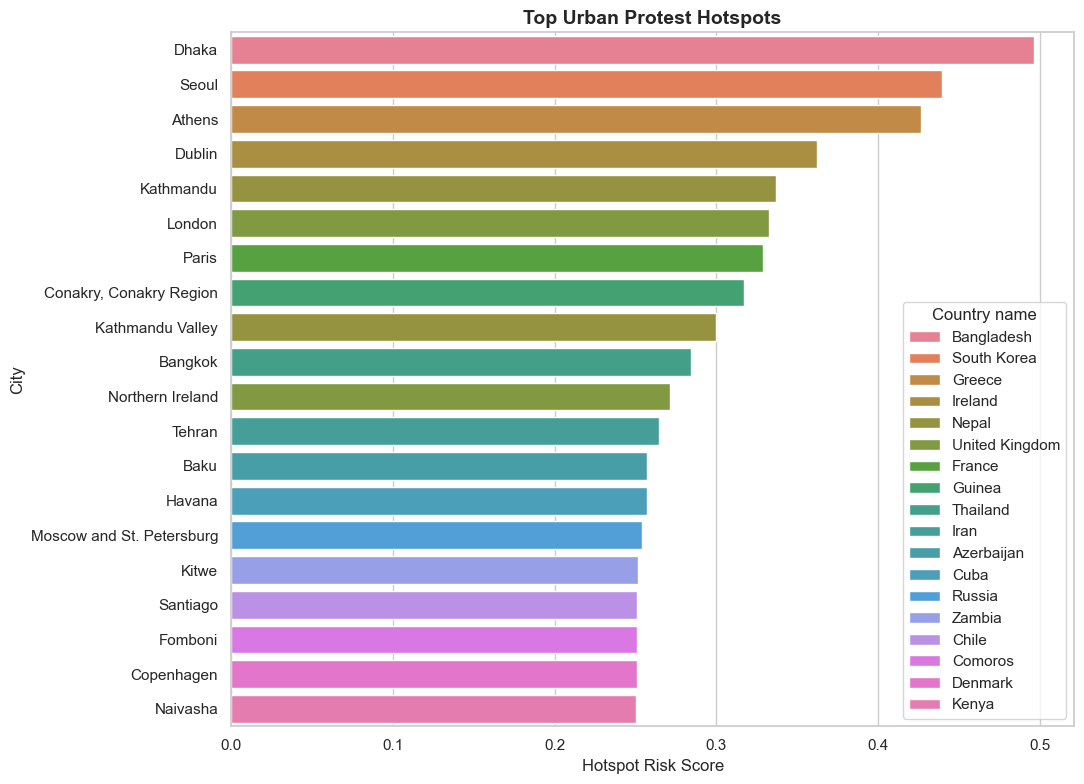

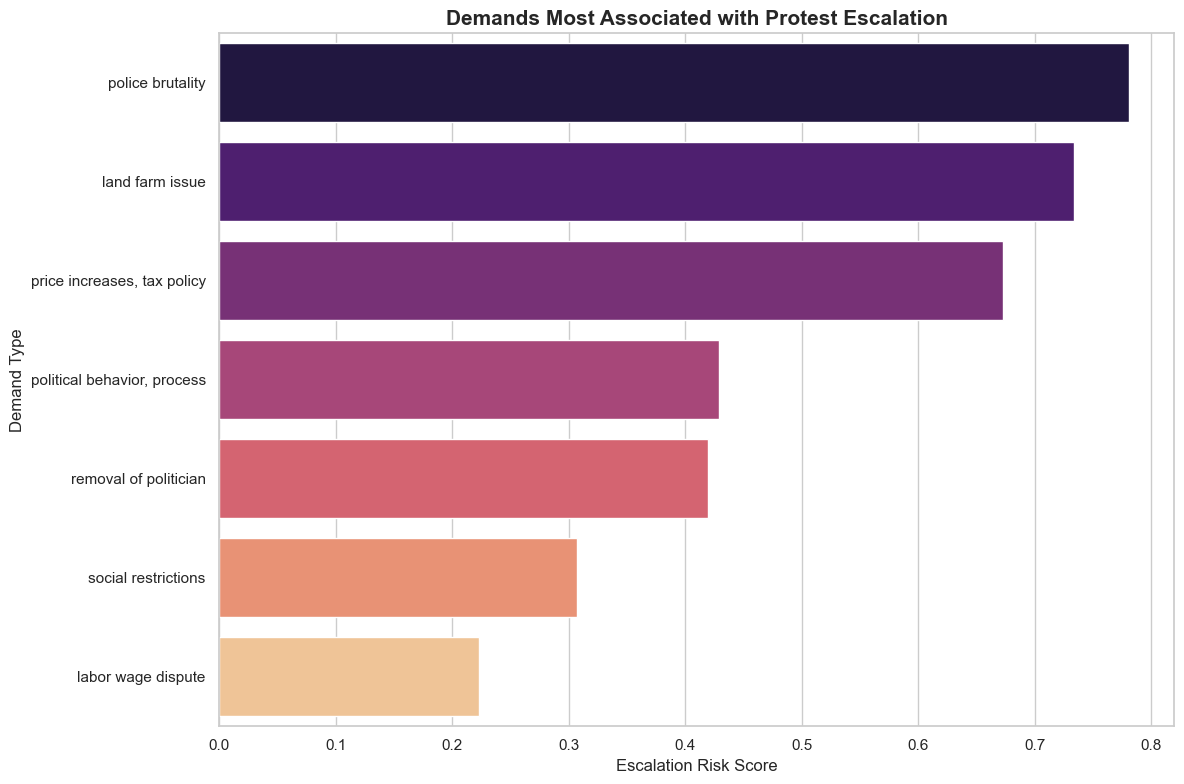

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="flare")

# ============================
# Load Data
# ============================
df = pd.read_csv("Protest_pg_ready.csv", sep=";", low_memory=False)

# ============================
# Basic Cleaning
# ============================
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Protester Violence"] = pd.to_numeric(df["Protester Violence"], errors="coerce").fillna(0)

response_col = "Primary State Response to protests [Response 1]"
df[response_col] = df[response_col].fillna("").astype(str)

# ============================
# Repression Proxy
# ============================
repression_keywords = [
    "repression", "arrest", "police", "force", "violence", "crackdown"
]

df["is_repression"] = df[response_col].str.contains(
    "|".join(repression_keywords),
    case=False,
    regex=True,
    na=False
).astype(int)

# ============================
# Protest Duration
# ============================
df["start_date"] = pd.to_datetime(
    dict(year=df["Start Year"], month=df["Start Month"], day=df["Start Day"]),
    errors="coerce"
)

df["end_date"] = pd.to_datetime(
    dict(year=df["End Year"], month=df["End Month"], day=df["End Day"]),
    errors="coerce"
)

df["duration_days"] = (df["end_date"] - df["start_date"]).dt.days
df["duration_days"] = df["duration_days"].clip(lower=0)


df["duration_days"] = df["duration_days"].fillna(0)

# ============================
# Duration Buckets
# ============================
bins = [-1, 0, 1, 3, 7, 14, 30, 365]
labels = [
    "Same-day",
    "1 day",
    "2-3 days",
    "4-7 days",
    "8-14 days",
    "15-30 days",
    "30+ days"
]

df["duration_bucket"] = pd.cut(df["duration_days"], bins=bins, labels=labels)

# ============================
# 1) Duration → Violence
# ============================
duration_violence = df.groupby("duration_bucket", observed=False).agg(
    protest_count=("Protest ID #", "count"),
    violence_rate=("Protester Violence", "mean"),
    repression_rate=("is_repression", "mean")
).reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=duration_violence,
    x="duration_bucket",
    y="violence_rate",
    marker="o",
    linewidth=2.5,
    color="#D7263D"
)
plt.title("How Protest Duration Relates to Protester Violence", fontsize=14, weight="bold")
plt.xlabel("Protest Duration")
plt.ylabel("Violence Rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ============================
# 2) Duration → Repression
# ============================
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=duration_violence,
    x="duration_bucket",
    y="repression_rate",
    marker="o",
    linewidth=2.5,
    color="#1B4965"
)
plt.title("How Protest Duration Relates to State Repression", fontsize=14, weight="bold")
plt.xlabel("Protest Duration")
plt.ylabel("Repression Rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ============================
# 3) Violence vs Repression Quadrant
# ============================
country_matrix = df.groupby("Country name").agg(
    protest_count=("Protest ID #", "count"),
    violence_rate=("Protester Violence", "mean"),
    repression_rate=("is_repression", "mean"),
    avg_duration=("duration_days", "mean")
).reset_index()


country_matrix = country_matrix[country_matrix["protest_count"] >= 20]

v_med = country_matrix["violence_rate"].median()
r_med = country_matrix["repression_rate"].median()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=country_matrix,
    x="repression_rate",
    y="violence_rate",
    size="protest_count",
    hue="avg_duration",
    sizes=(50, 500),
    palette="viridis",
    alpha=0.8
)

plt.axvline(r_med, linestyle="--", color="gray")
plt.axhline(v_med, linestyle="--", color="gray")

plt.title("Country Risk Quadrants: Violence vs Repression", fontsize=14, weight="bold")
plt.xlabel("State Repression Rate")
plt.ylabel("Protester Violence Rate")
plt.tight_layout()
plt.show()

# ============================
# 4) City Hotspot Risk
# ============================
invalid_locations = [
    "nationwide", "national", "national level", "nan",
    "various", "multiple cities", "countrywide", ""
]

df["Location of Protest"] = df["Location of Protest"].fillna("").astype(str).str.strip()

city_df = df[~df["Location of Protest"].str.lower().isin(invalid_locations)].copy()

city_risk = city_df.groupby(["Country name", "Location of Protest"]).agg(
    protest_count=("Protest ID #", "count"),
    violence_rate=("Protester Violence", "mean"),
    repression_rate=("is_repression", "mean"),
    avg_duration=("duration_days", "mean")
).reset_index()

city_risk = city_risk[city_risk["protest_count"] >= 5]

def normalize(s):
    if s.max() == s.min():
        return pd.Series(0, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

city_risk["hotspot_score"] = (
    0.35 * normalize(city_risk["protest_count"]) +
    0.25 * normalize(city_risk["violence_rate"]) +
    0.25 * normalize(city_risk["repression_rate"]) +
    0.15 * normalize(city_risk["avg_duration"])
)

city_risk = city_risk.sort_values("hotspot_score", ascending=False)

top_cities = city_risk.head(20)

plt.figure(figsize=(11, 8))
sns.barplot(
    data=top_cities,
    y="Location of Protest",
    x="hotspot_score",
    hue="Country name",
    dodge=False
)
plt.title("Top Urban Protest Hotspots", fontsize=14, weight="bold")
plt.xlabel("Hotspot Risk Score")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# ============================
# 5)Demand-to-Risk Analysis
# ============================

demand_cols = [
    "Primary Protester Demands [Demand 1]",
    "Primary Protester Demands [Demand 2]",
    "Primary Protester Demands [Demand 3]",
    "Primary Protester Demands [Demand 4]"
]

demands_long = df.melt(
    id_vars=["Protester Violence", "is_repression", "duration_days", "Protest ID #"],
    value_vars=demand_cols,
    value_name="Demand"
)

demands_long["Demand"] = demands_long["Demand"].fillna("").astype(str).str.strip()
demands_long = demands_long[demands_long["Demand"] != ""]

demand_risk = demands_long.groupby("Demand").agg(
    protest_count=("Protest ID #", "count"),
    violence_rate=("Protester Violence", "mean"),
    repression_rate=("is_repression", "mean"),
    avg_duration=("duration_days", "mean")
).reset_index()

demand_risk = demand_risk[demand_risk["protest_count"] >= 30]

demand_risk["risk_score"] = (
    0.4 * normalize(demand_risk["violence_rate"]) +
    0.35 * normalize(demand_risk["repression_rate"]) +
    0.25 * normalize(demand_risk["avg_duration"])
)

top_demands = demand_risk.sort_values("risk_score", ascending=False).head(15)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_demands,
    y="Demand",
    x="risk_score",
    hue="Demand",
    palette="magma",
    legend=False
)

plt.title("Demands Most Associated with Protest Escalation", fontsize=15, weight="bold")
plt.xlabel("Escalation Risk Score")
plt.ylabel("Demand Type")

plt.tight_layout()
plt.show()
